In [25]:
import zipfile
import os

# Define paths for the zip file and where to extract its contents
zip_path = '/content/archive.zip'
output_dir = '/content/'

# Open the zip file and extract all its contents to the specified output directory
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

# List files in the output directory to confirm extraction and identify the CSV file name
print(os.listdir(output_dir))

['.config', 'netflix_titles.csv', 'archive.zip', 'sample_data']


In [2]:
import pandas as pd

### Load Data

In [26]:
# Load the dataset from the CSV file into a pandas DataFrame
df = pd.read_csv('/content/netflix_titles.csv')

# Display the number of rows and columns (shape) of the DataFrame
print(f"Dataset shape: {df.shape}")

Dataset shape: (8807, 12)


### Initial Data Inspection

In [4]:
# Get concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Peek at Data

In [5]:
# Display the first 5 rows
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Check Missing Values

In [6]:
# Calculate the number of missing values per column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


### Initial Data Observations

Initial inspection revealed missing values in `director`, `cast`, `country`, `date_added`, and `duration`. Additionally, `date_added` and `duration` require format corrections.

## 2. Clean up the Dataset

### Handle Missing Values

Missing values in `director`, `cast`, and `country` were filled with 'Unknown' or 'No Data'. Rows with missing `date_added` or `duration` were dropped. The `rating` column's missing values were filled with the mode.

In [27]:
# Fill missing values in 'director', 'cast', and 'country' columns with 'Unknown' or 'No Data'
# Using inplace=True modifies the DataFrame directly without needing to reassign.
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('No Data', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Drop rows where 'date_added' or 'duration' is missing.
# These columns are critical for time analysis and content duration, so dropping a few rows is acceptable.
df.dropna(subset=['date_added', 'duration'], inplace=True)

# Find the most frequent rating in the 'rating' column
most_frequent_rating = df['rating'].mode()[0]
# Fill any missing 'rating' values with this most frequent rating
df['rating'].fillna(most_frequent_rating, inplace=True)

print("Missing values after initial fill/drop:")
print(df.isnull().sum())

Missing values after initial fill/drop:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


/tmp/ipykernel_1212/49466598.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1212/49466598.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

### Convert `date_added` to Datetime

In [21]:
# Convert 'date_added' to datetime objects. 'errors="coerce"' turns unparseable dates into NaT.
# 'format="mixed"' allows pandas to infer various date formats in the column.
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')

# Check the data type to confirm the change to datetime
print("Data type of 'date_added' after conversion:")
print(df['date_added'].dtype)
# Check for any remaining missing values in 'date_added' after conversion (from coerced errors)
print("\nMissing values in 'date_added' after conversion:")
print(df['date_added'].isnull().sum())

Data type of 'date_added' after conversion:
datetime64[ns]

Missing values in 'date_added' after conversion:
0


### Remove Duplicate Rows

In [28]:
# Count the number of perfectly duplicated rows in the DataFrame before removal
duplicates_before = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_before}")

# Remove duplicate rows from the DataFrame, keeping the first occurrence
df.drop_duplicates(inplace=True)

# Count duplicates again to confirm removal
duplicates_after = df.duplicated().sum()
print(f"Number of duplicate rows after removal: {duplicates_after}")

# Print the new shape of the DataFrame after duplicate removal
print(f"Dataset shape after duplicate removal: {df.shape}")

Number of duplicate rows found: 0
Number of duplicate rows after removal: 0
Dataset shape after duplicate removal: (8794, 12)


### Fix `duration` Column

The `duration` column was split into `duration_value` (numeric) and `duration_unit` (string) for better analysis.

In [29]:
# Split the 'duration' column (e.g., '93 min' or '2 Seasons') into two new columns.
# 'expand=True' makes sure the split parts become separate columns directly.
df[['duration_value', 'duration_unit']] = df['duration'].str.split(' ', expand=True)

# Convert 'duration_value' to a numeric type. 'errors="coerce"' will turn any values that can't be converted into NaN.
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

# Display the original 'duration' alongside the newly created 'duration_value' and 'duration_unit' for verification
display(df[['duration', 'duration_value', 'duration_unit']].head())

,duration,duration_value,duration_unit
0,90 min,90,min
1,2 Seasons,2,Seasons
2,1 Season,1,Season
3,1 Season,1,Season
4,2 Seasons,2,Seasons


### Final Cleaning Check

In [11]:
# Final info check
df.info()

# Final missing values check
print("\nMissing values after all cleaning:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         8794 non-null   object
 1   type            8794 non-null   object
 2   title           8794 non-null   object
 3   director        8794 non-null   object
 4   cast            8794 non-null   object
 5   country         8794 non-null   object
 6   date_added      8794 non-null   object
 7   release_year    8794 non-null   int64 
 8   rating          8794 non-null   object
 9   duration        8794 non-null   object
 10  listed_in       8794 non-null   object
 11  description     8794 non-null   object
 12  duration_value  8794 non-null   int64 
 13  duration_unit   8794 non-null   object
dtypes: int64(2), object(12)
memory usage: 1.0+ MB

Missing values after all cleaning:
show_id           0
type              0
title             0
director          0
cast              0
country

## 3. Explore Data with Plots

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

### Movies vs TV Shows

/tmp/ipykernel_1212/3127648817.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


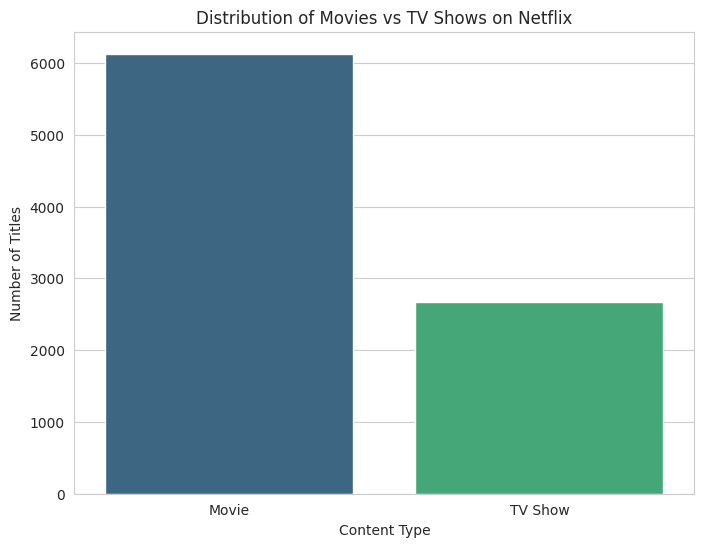

In [30]:
# Set the figure size for better visualization
plt.figure(figsize=(8, 6))
# Create a count plot to visualize the distribution of 'type' (Movie vs. TV Show)
sns.countplot(x='type', data=df, palette='viridis')
# Add a title and labels for the axes
plt.title('Distribution of Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
# Display the plot
plt.show()

**Takeaway**: Netflix's library contains more movies than TV shows.

### Top Content-Producing Countries

/tmp/ipykernel_1212/3019404487.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')


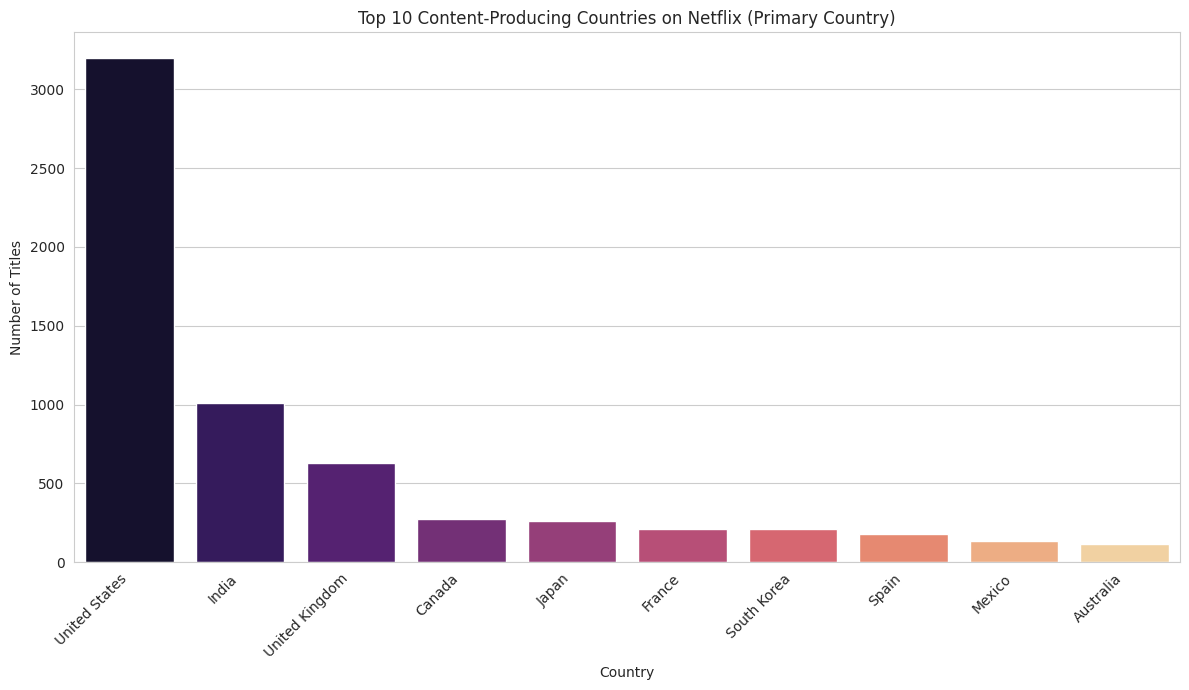

In [31]:
# Filter out 'Unknown' countries and then take the first country listed for each entry.
# Use value_counts() to get the frequency of each country and select the top 10.
top_countries = df[df['country'] != 'Unknown']['country'].apply(lambda x: x.split(',')[0].strip()).value_counts().head(10)

# Set the figure size
plt.figure(figsize=(12, 7))
# Create a bar plot for the top 10 content-producing countries
sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')
plt.title('Top 10 Content-Producing Countries on Netflix (Primary Country)')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
# Adjust layout to prevent labels from overlapping
plt.tight_layout()
plt.show()

**Takeaway**: The USA is the primary content-producing country.

### Ratings Distribution

/tmp/ipykernel_1212/2933767560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='plasma')


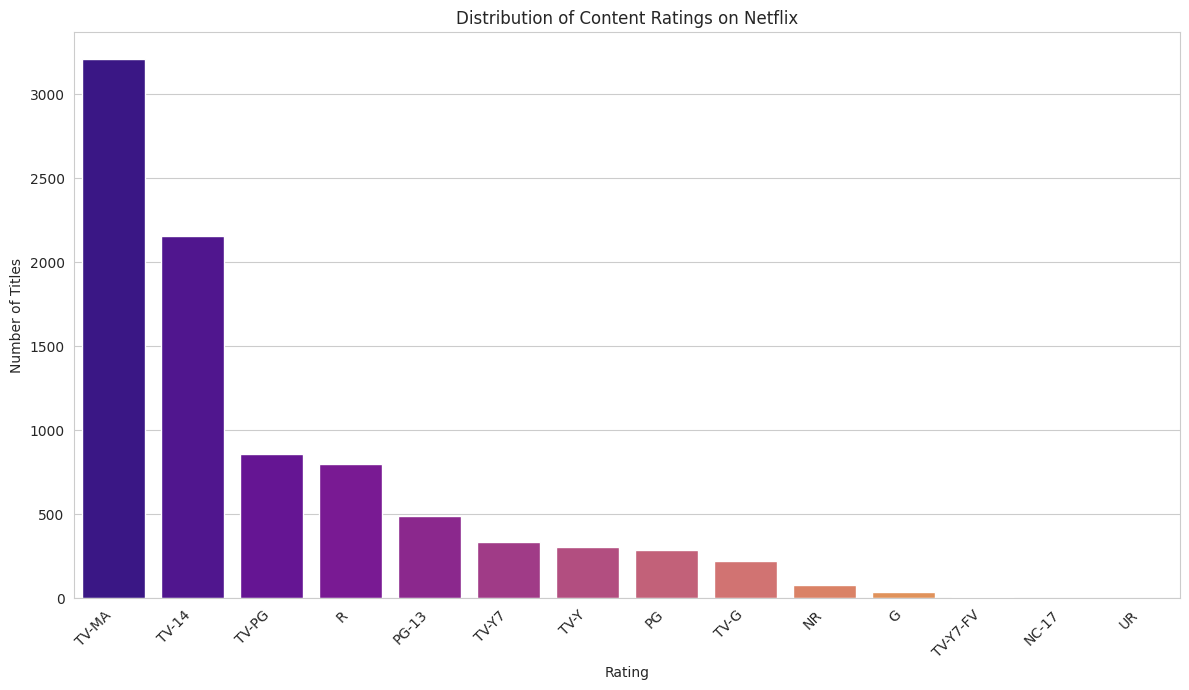

In [15]:
plt.figure(figsize=(12, 7))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='plasma')
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway**: 'TV-MA' is the most common content rating on Netflix.

### Content Added Per Year

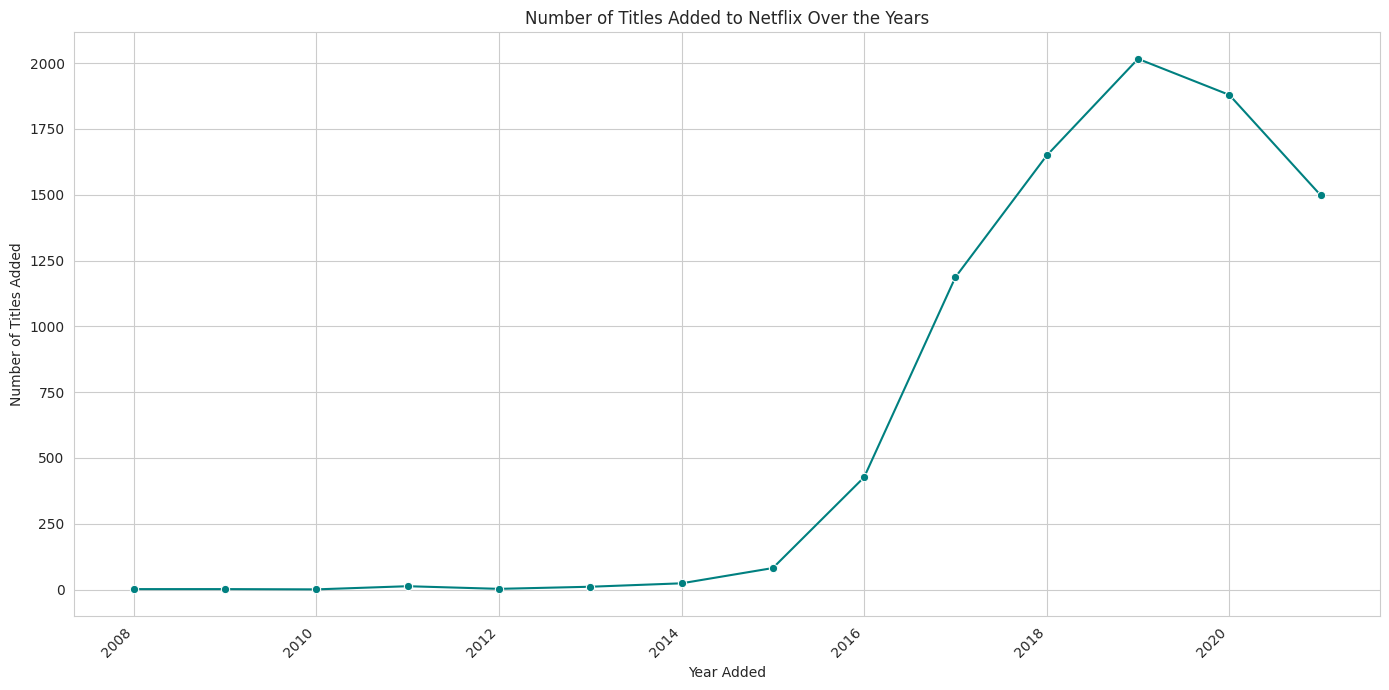

In [22]:
# Extract the year component from the 'date_added' datetime objects and store it in a new column
df['year_added'] = df['date_added'].dt.year

# Count the number of titles added for each year and sort the results by year
content_per_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
# Create a line plot to show the trend of content added over the years
sns.lineplot(x=content_per_year.index, y=content_per_year.values, marker='o', color='teal')
plt.title('Number of Titles Added to Netflix Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway**: The number of content additions peaked between 2019 and 2020.

### Release Year vs. Year Added

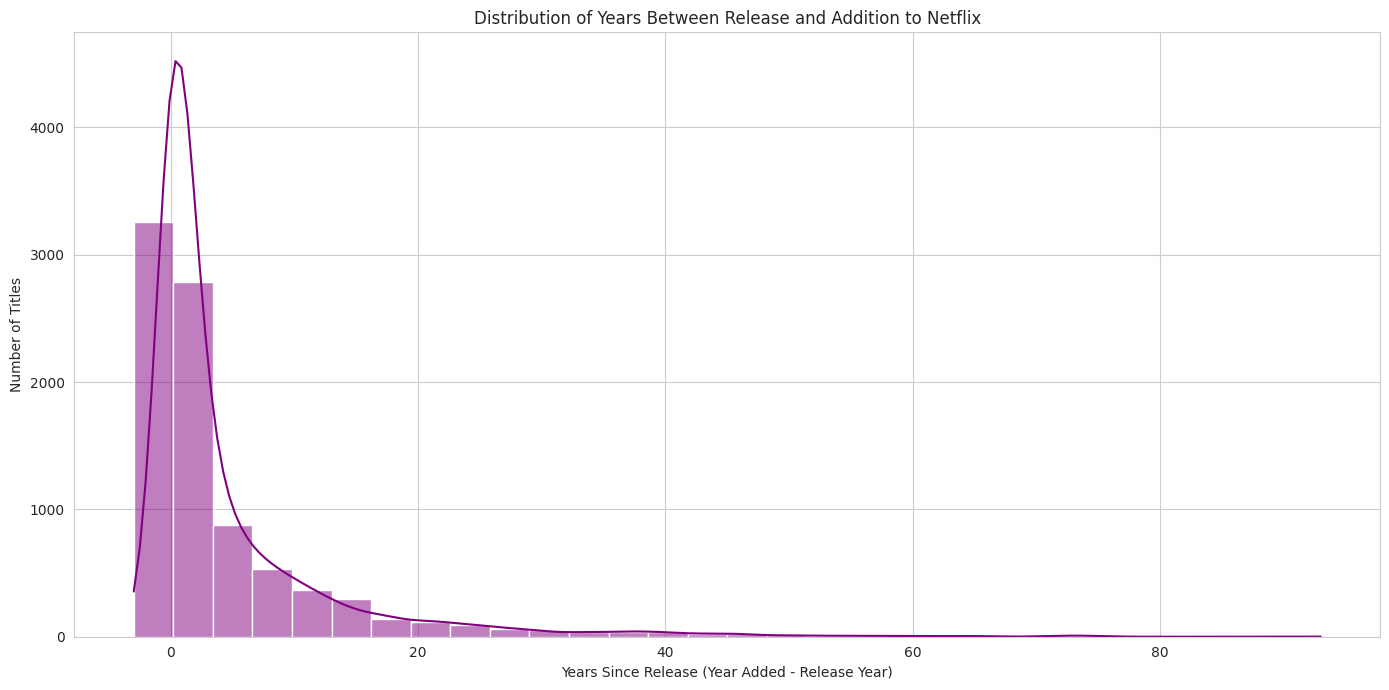

In [23]:
# Calculate the difference between 'year_added' and 'release_year' to find how old content is when added
df['years_since_release'] = df['year_added'] - df['release_year']

plt.figure(figsize=(14, 7))
# Create a histogram to visualize the distribution of 'years_since_release'
# kde=True adds a Kernel Density Estimate plot for smoothing
sns.histplot(df['years_since_release'], bins=30, kde=True, color='purple')
plt.title('Distribution of Years Between Release and Addition to Netflix')
plt.xlabel('Years Since Release (Year Added - Release Year)')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

**Takeaway**: Most content was added to Netflix within 0-5 years of its original release.

## 4. Analyze Multi-valued Columns

### Analyze `listed_in` (Genres)

/tmp/ipykernel_1212/4048566155.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')


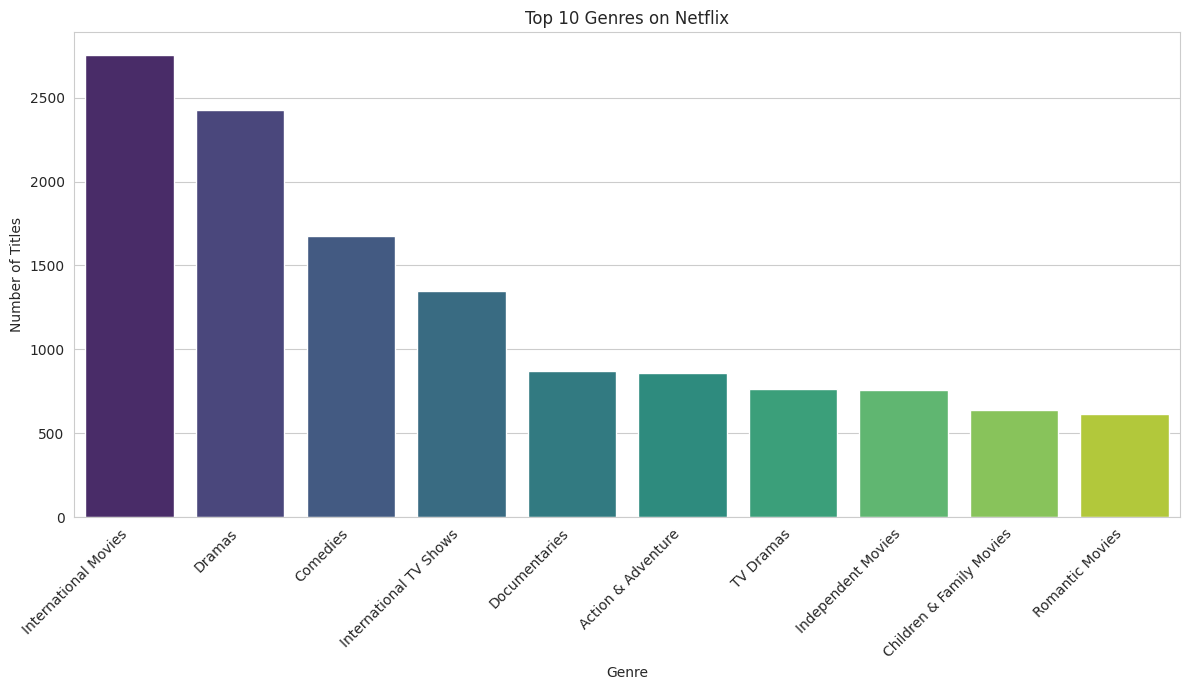

In [32]:
# Split the 'listed_in' string (e.g., 'Dramas, International Movies') into individual genres.
# .explode() transforms each element of a list-like entry to a separate row.
genres = df['listed_in'].str.split(', ').explode()

# Count the occurrences of each genre and get the top 10
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 7))
# Create a bar plot to show the top 10 genres
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway**: 'International Movies' and 'Dramas' are the top genres on Netflix.

### Analyze `cast` (Top Actors/Actresses)

/tmp/ipykernel_1212/3238653774.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cast.index, y=top_cast.values, palette='magma')


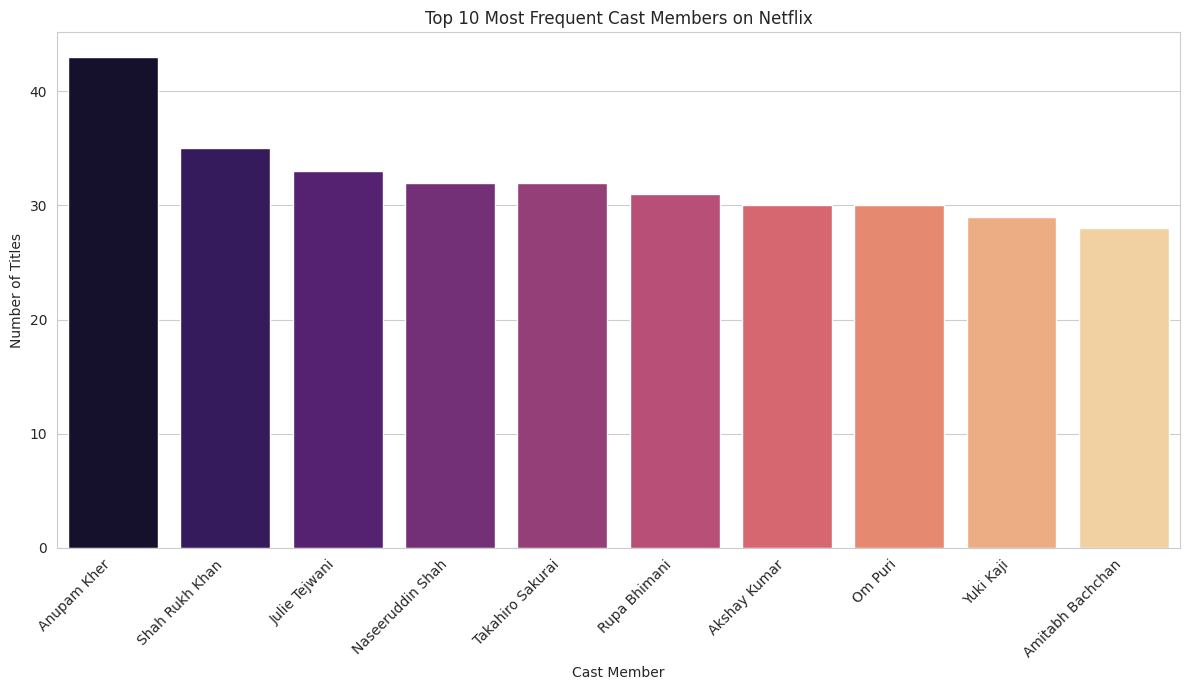

In [33]:
# Filter out entries where 'cast' was filled with 'No Data', then split the string into individual cast members.
# .explode() creates a new row for each cast member in a multi-valued entry.
cast_members = df[df['cast'] != 'No Data']['cast'].str.split(', ').explode()

# Count the occurrences of each cast member and get the top 10 most frequent
top_cast = cast_members.value_counts().head(10)

plt.figure(figsize=(12, 7))
# Create a bar plot to visualize the top 10 most frequent cast members
sns.barplot(x=top_cast.index, y=top_cast.values, palette='magma')
plt.title('Top 10 Most Frequent Cast Members on Netflix')
plt.xlabel('Cast Member')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway**: Anupam Kher and Shah Rukh Khan are among the most frequent cast members.

## 5. Comparison: Movies vs. TV Shows Added Annually

<Figure size 1400x700 with 0 Axes>

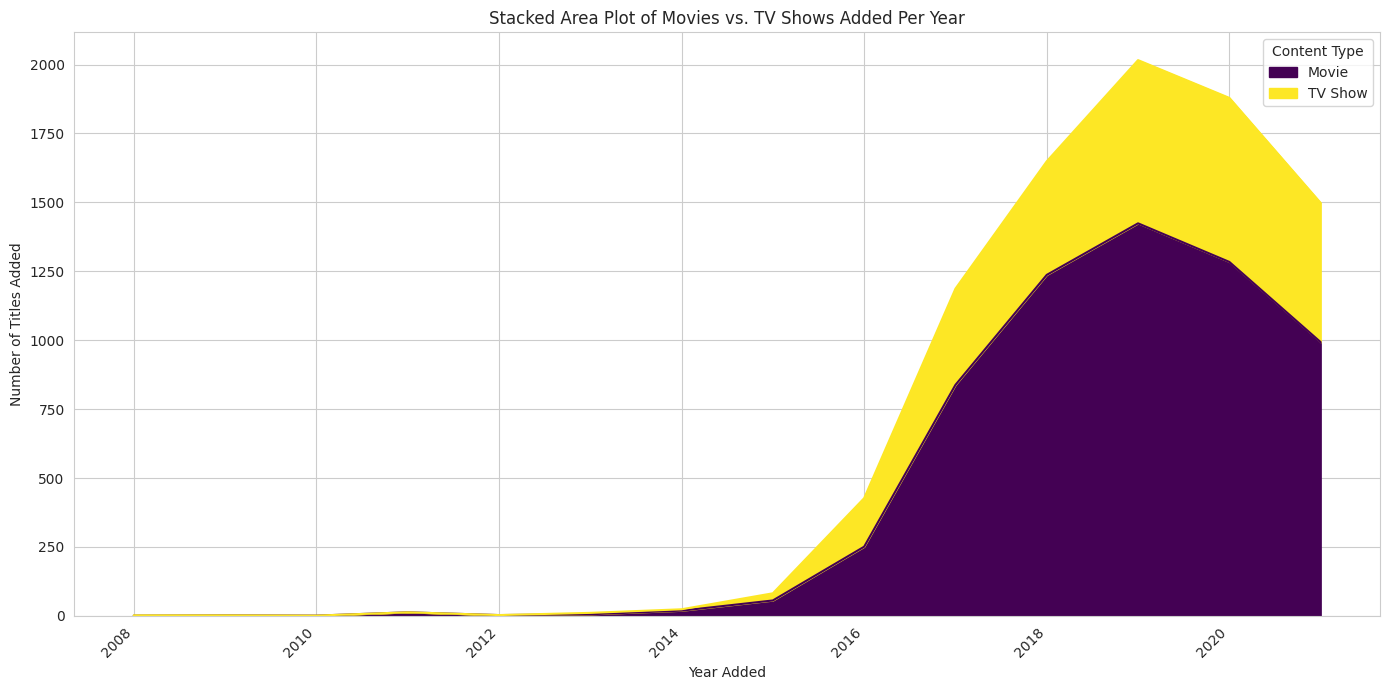

In [24]:
# Group the DataFrame by the year content was added and by its type (Movie/TV Show).
# .size() counts the number of entries in each group, .unstack() pivots 'type' to columns.
# .fillna(0) replaces any missing combinations with zero.
content_type_over_time = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

# Filter the data to include years from 2008 onwards, as earlier years have minimal data.
content_type_over_time = content_type_over_time[content_type_over_time.index >= 2008]

plt.figure(figsize=(14, 7))
# Create a stacked area plot to show the trend of movies vs. TV shows added over time.
content_type_over_time.plot(kind='area', stacked=True, colormap='viridis', figsize=(14, 7))
plt.title('Stacked Area Plot of Movies vs. TV Shows Added Per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

**Takeaway**: Both content types increased, peaking between 2019-2020; movies consistently outnumber TV shows.

## 7. README.md: Key Insights

*   Netflix's content library is movie-heavy.
*   The US dominates content production.
*   Content is largely geared towards a mature audience.
*   There was a significant content acquisition boom around 2019-2020.

## 8. Bonus: Streamlit Dashboard Plan

An interactive Streamlit dashboard would include filters and dynamic plots for content exploration.

## 9. Bonus: Data Inconsistency - `duration` column

The `duration` column had mixed units ('min' and 'Seasons'). It was split into `duration_value` and `duration_unit` for proper analysis.

## 10. Bonus: Statistical Test - Content Type Distribution

A Chi-square test was performed to compare movie/TV show counts against an equal distribution.

In [34]:
from scipy.stats import chi2_contingency

# Get the counts of Movies and TV Shows
content_counts = df['type'].value_counts()
print("Observed content counts:\n", content_counts)

# We want to test if the proportions are significantly different from each other.
# For a goodness-of-fit test comparing two categories against expected equal proportions (50/50),
# we can define expected counts. However, a simpler way to validate the 'heavy' claim
# is to consider it a 2x1 contingency table and compare it to a uniform distribution, or
# more directly, simply look at the overwhelming visual difference if not testing for a specific hypothesized ratio.
# A more suitable test to confirm the observed 'movie-heavy' claim is to test if these proportions are significantly different.
# Let's perform a chi-square test of independence if we had another categorical variable, or simply confirm a strong deviation from 50/50.

# Let's just create a simplified expected if we assume they should be roughly equal (for demonstration of 'heavy')
total_content = content_counts.sum()
expected_equal = [total_content / 2, total_content / 2]

# For a chi-square test of independence, we need a contingency table.
# Since we are comparing observed counts to expected counts for a single variable,
# we'll use chi2_contingency on a simple 2x1 array for observed and a hypothetical expected for comparison.
# Or more straightforward for a claim like 'movie-heavy', we can just perform a chi-squared test for observed vs. expected proportions.

# Let's frame it as a comparison of proportions against a null of equal distribution.
# Observed frequencies
observed = [content_counts['Movie'], content_counts['TV Show']]

# Expected frequencies if distribution were equal (null hypothesis)
expected = [total_content / 2, total_content / 2]

# Perform the chi-square test for goodness of fit
# Using chi2_contingency for a 1-D observed array with expected values
# The result will be (chi2_statistic, p_value, degrees_of_freedom, expected_frequencies_array)
chi2_statistic, p_value = chi2_contingency([observed, expected])[0:2]

print(f"\nChi-square statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.3e}") # Using scientific notation for small p-values

Observed content counts:
 type
Movie      6128
TV Show    2666
Name: count, dtype: int64

Chi-square statistic: 708.10
P-value: 5.168e-156


### Chi-square Test Result

**Conclusion**: The null hypothesis of equal content distribution is rejected. This statistically supports the claim that Netflix's library is movie-heavy.

**Takeaway**: Both content types increased, peaking between 2019-2020; movies consistently outnumber TV shows.